# Visualizing Social Vulnerability in Counties Affected by Hurricane Helene

```{image} ../thumbnails/U.S._Census_Bureau_logo_post-2011.svg.png
:alt: US Census Bureau logo
:width: 200px
```

---

## Overview

46.5% of the counties affected by Hurricane Helene had higher-than-average social vulnerability estimates, compared to the national percentage of 30.1% of counties with higher-than-average social vulnerability estimates. Higher-than-average percentages of people living in rural areas compared to the national average were also seen in the affected counties, leading to increased difficulties for recovery efforts post-storm. Other socioeconomic vulnerabilities, such as poverty levels, also impacted the aftermath of Hurricane Helene. 

---

## Import Packages

In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt
import pandas as pd
from cartopy import crs as ccrs
from cartopy import feature as cfeature
from metpy.plots import USCOUNTIES

---

## Import CSV Data as a Pandas DataFrame

In notebook1, we merged two dataframes: the [**Census Bureau’s Assessment, Recovery, and Evaluation datasets or CAREs**](https://www.census.gov/programs-surveys/community-resilience-estimates/projects/disaster-recovery/hurricane-helene.html) dataset from the US Census Bureau and the [**GeoPandas’ built-in TIGER/Cartographic Boundary files**](https://www2.census.gov/geo/tiger/GENZ2022) from the U.S. Census Bureau. The merging of these two datasets created a new CSV file called helene_merged.csv, which includes population, exposure, and recovery data for Hurricane Helene, as well as the polygon geometry of the counties. We will now import the helene_merged.csv as a Pandas DataFrame.

In [2]:
helene_merged = pd.read_csv('/spare11/atm533/ag265895/proto-cookbook/data/helene_merged.csv')

The county geometry column in helene_merged was stored as a WKT string so it needs to be converted to a Shapely geometry format in order for GeoPandas to be able to recognize it as a polygon

In [3]:
helene_merged['geometry'] = helene_merged['geometry'].apply(wkt.loads)

Now that the geometry column has been properly converted, we can convert helene_merged to a GeoDataFrame, allowing us to plot the polygons. We will also ensure that the geometries are in the same coordinate reference system (CRS) as the map we are using.

In [4]:
helene_merged = gpd.GeoDataFrame(helene_merged, geometry='geometry', crs="EPSG:4326")

Recall that this dataset includes the 299 counties which issued Presidential Disaster Declarations as a result of Hurricane Helene. We will now visualize some social vulnerability parameters such as povery level percentages, social vulnerability levels, and rurality percentages. 

---

## Visualizing Poverty Level Percentages

The SAEPOVRTALL_PT_23 column from the DataFrame tells us the rate estimate of all ages in poverty over the counties which issues a Presidential Disaster Declaration. Using .describe() lets us see some statistics from the column.

In [5]:
#summary stats (min, max, mean, etc.)
print(helene_merged['SAEPOVRTALL_PT_23'].describe())

count    299.000000
mean      17.419064
std        5.696956
min        6.300000
25%       13.350000
50%       16.800000
75%       21.400000
max       37.200000
Name: SAEPOVRTALL_PT_23, dtype: float64


Now that we have an idea of the contents of the column, lets see the distribution of the poverty levels geographically.

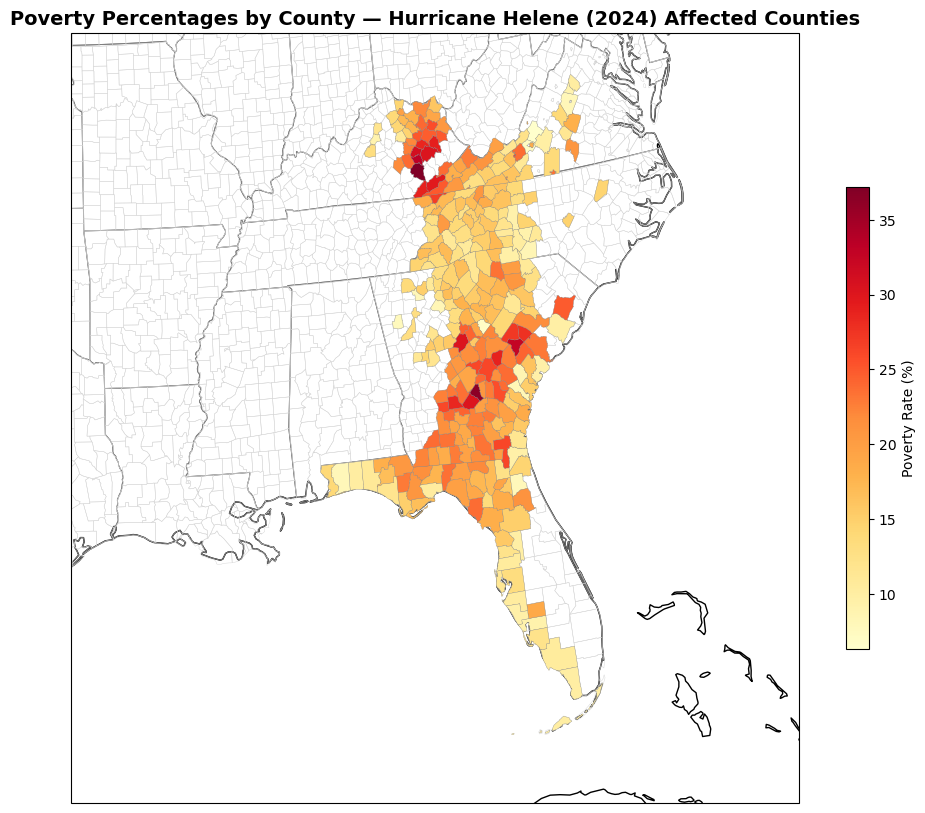

In [9]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

#plot counties shaded by poverty rate
helene_merged.plot(
    column='SAEPOVRTALL_PT_23',      
    cmap='YlOrRd',                      
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "Poverty Rate (%)", 'shrink': 0.6},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

#add title
plt.title('Poverty Percentages by County — Hurricane Helene (2024) Affected Counties', fontsize=14, weight='bold')

plt.show()

---

## Visualizing Rurality

Let's see how this spatial distribution of poverty compares to the spatial distribution of rurality. We can use the column RURAL_POP_DEC_2020 to see the number of people living in rural areas as recorded by the 2020 U.S. Census

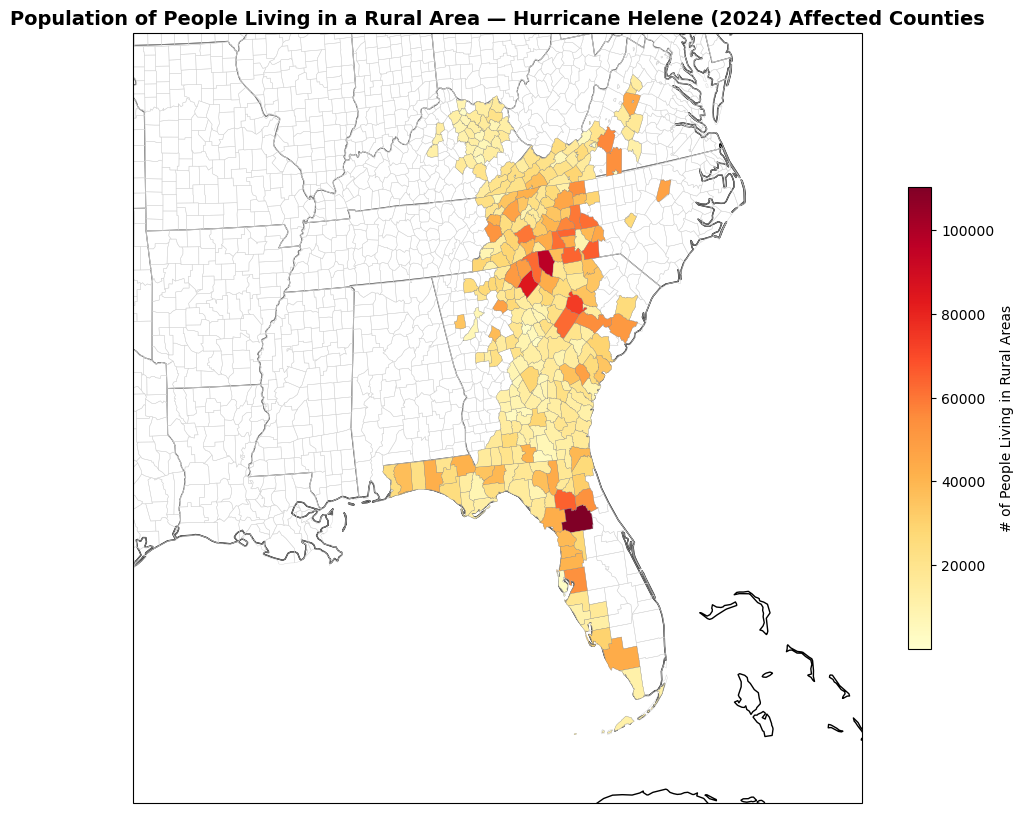

In [11]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

#plot counties shaded by poverty rate
helene_merged.plot(
    column='RURAL_POP_DEC_2020',      
    cmap='YlOrRd',                      
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "# of People Living in Rural Areas", 'shrink': 0.6},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

#add title
plt.title('Population of People Living in a Rural Area — Hurricane Helene (2024) Affected Counties', fontsize=14, weight='bold')

plt.show()

---

## Summary

This notebook read in the helene_merged.csv we created in notebook1, but we also had to ensure that the geometry column was readable. We converted the MKT String to Shapely Geometry in order to convert helene_merged to a GeoDataFrame so the geometry column could be read as polygons. After that, this notebook plotted poverty level percetages using data from helene_merged as well as amount of people living in rural areas in the counties where Hurricane Helene led to a presidential disaster declaration.